<a href="https://colab.research.google.com/github/dikshi-shah/Crop-yield-prediction/blob/main/Crop_yield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
data = pd.read_csv('/content/crop-yield.csv')
display(data.head(5))

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Crop_Type,Irrigation_Type,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
0,132,62,22,6.35,59.78,Clay,0.43,22.97,53.89,1305.68,7.73,15.96,Central,36,Rabi,Maize,Canal,223.48,23.36,11.42
1,122,71,66,5.98,25.54,Sandy,0.65,17.00,76.90,1942.05,9.25,12.60,North,1561,Rabi,Potato,Canal,161.54,4.42,23.19
2,44,35,104,8.07,25.87,Sandy,0.79,25.52,44.78,2216.20,8.50,15.63,North,1870,Rabi,Rice,Rainfed,184.62,6.29,7.94
3,136,96,113,4.83,42.97,Silt,0.45,18.59,31.89,607.18,8.75,5.49,East,765,Kharif,Sugarcane,Rainfed,274.02,2.72,72.53
4,101,34,42,5.84,48.01,Silt,0.69,22.74,46.27,483.47,8.00,7.44,Central,1143,Zaid,Wheat,Rainfed,72.69,15.37,6.72


In [3]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
data['Soil_Type'] = label.fit_transform(data['Soil_Type'])
data['Region'] = label.fit_transform(data['Region'])
data['Season'] = label.fit_transform(data['Season'])
data['Crop_Type'] = label.fit_transform(data['Crop_Type'])
data['Irrigation_Type'] = label.fit_transform(data['Irrigation_Type'])

In [4]:
X = data.drop('Crop_Yield_ton_per_hectare', axis=1)
y = data['Crop_Yield_ton_per_hectare']

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,MinMaxScaler
import pickle

scaling_pipeline_X = Pipeline([
    ('scaler', StandardScaler()),
    ('minmax', MinMaxScaler())
])

X_train = pd.DataFrame(scaling_pipeline_X.fit_transform(X_train), columns=X_train.columns)
X_val = pd.DataFrame(scaling_pipeline_X.transform(X_val), columns=X_val.columns)
X_test = pd.DataFrame(scaling_pipeline_X.transform(X_test), columns=X_test.columns)

y_scaler = MinMaxScaler()

y_train = pd.Series(y_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten(), index=y_train.index)
y_val = pd.Series(y_scaler.transform(y_val.values.reshape(-1, 1)).flatten(), index=y_val.index)
y_test = pd.Series(y_scaler.transform(y_test.values.reshape(-1, 1)).flatten(), index=y_test.index)

with open('scalers.pkl', 'wb') as f:
    pickle.dump((scaling_pipeline_X, y_scaler), f)

In [6]:
from sklearn.feature_selection import mutual_info_regression, SelectKBest
import pandas as pd

mutual_info = mutual_info_regression(X_train, y_train)

mutual_info_series = pd.Series(mutual_info, name='Mutual_Info_Score', index=X_train.columns)
print("Mutual Information Scores (sorted descending):\n", mutual_info_series.sort_values(ascending=False))

sel_cols = SelectKBest(mutual_info_regression, k=14)
sel_cols.fit(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': sel_cols.scores_
})

feature_scores = feature_scores.sort_values(by='Score', ascending=False)

# Print the top 14 features and their scores
print("\nTop 14 Features by Mutual Information Score:\n", feature_scores.head(14))

Mutual Information Scores (sorted descending):
 Crop_Type          0.950412
Fertilizer_Used    0.130153
Rainfall           0.087825
Soil_Moisture      0.035942
Wind_Speed         0.019894
Soil_pH            0.017704
Sunlight_Hours     0.015199
N                  0.013602
P                  0.011473
Soil_Type          0.008154
K                  0.007931
Temperature        0.006176
Irrigation_Type    0.002941
Humidity           0.001101
Organic_Carbon     0.000000
Season             0.000000
Altitude           0.000000
Region             0.000000
Pesticide_Used     0.000000
Name: Mutual_Info_Score, dtype: float64

Top 14 Features by Mutual Information Score:
             Feature     Score
15        Crop_Type  0.957364
17  Fertilizer_Used  0.129822
9          Rainfall  0.087919
4     Soil_Moisture  0.035613
11       Wind_Speed  0.021333
3           Soil_pH  0.016763
10   Sunlight_Hours  0.016652
0                 N  0.014890
5         Soil_Type  0.014876
1                 P  0.011448
16 

In [7]:
X_train_selected = X_train.loc[:, sel_cols.get_support()]
X_val_selected = X_val.loc[:, sel_cols.get_support()]
X_test_selected = X_test.loc[:, sel_cols.get_support()]
X_train_selected = X_train_selected.astype(float)
X_val_selected = X_val_selected.astype(float)
X_test_selected = X_test_selected.astype(float)

MODEL 1 TRAINING

In [9]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(16),
  tf.keras.layers.Dense(25,activation='relu'),
  tf.keras.layers.Dense(36,activation='relu'),
  tf.keras.layers.Dense(48,activation = 'relu'),
  tf.keras.layers.Dense(64,activation = 'gelu'),
  tf.keras.layers.Dense(81),
  tf.keras.layers.Dense(1),
])

model_1.compile(loss='mae',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

model_1.fit(X_train_selected, y_train, epochs=40, validation_data=(X_val_selected, y_val))

Epoch 1/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1769 - mae: 0.1769 - val_loss: 0.1875 - val_mae: 0.1875
Epoch 2/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1694 - mae: 0.1694 - val_loss: 0.1821 - val_mae: 0.1821
Epoch 3/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1644 - mae: 0.1644 - val_loss: 0.1749 - val_mae: 0.1749
Epoch 4/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1549 - mae: 0.1549 - val_loss: 0.1534 - val_mae: 0.1534
Epoch 5/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1250 - mae: 0.1250 - val_loss: 0.0251 - val_mae: 0.0251
Epoch 6/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0285 - mae: 0.0285 - val_loss: 0.0302 - val_mae: 0.0302
Epoch 7/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0193 - mae: 0.0193 - val_loss: 0.0220 - val_mae: 0.0220
Epoch 8/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0166 - mae: 0.0166 - val_loss: 0.0183 - val_mae: 0.0183
Epoch 9/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [10]:
y_pred_scaled_1 = model_1.predict(X_test_selected)
model_1_results = model_1.evaluate(X_test_selected, y_test)
print(f"Test Loss: {model_1_results[0]:.4f}")
print(f"Test MAE: {model_1_results[1]:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0116 - mae: 0.0116 
Test Loss: 0.0117
Test MAE: 0.0117


In [11]:
from sklearn.metrics import mean_absolute_error

with open('scalers.pkl', 'rb') as f:
    scaling_pipeline_X, y_scaler = pickle.load(f)

y_test_original = y_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
y_pred_original_1 = y_scaler.inverse_transform(y_pred_scaled_1).flatten()

true_mae_1 = mean_absolute_error(y_test_original, y_pred_original_1)
print(f"Model 1 True MAE on original scale: {true_mae_1:.4f}")

results_df_1 = pd.DataFrame({
    'Actual Crop Yield': y_test_original,
    'Predicted Crop Yield': y_pred_original_1
})

display(results_df_1)

Model 1 True MAE on original scale: 0.9245


,Actual Crop Yield,Predicted Crop Yield
0,74.60,75.157715
1,24.70,24.569309
2,7.89,9.046291
3,77.25,75.276443
4,7.54,10.638817
...,...,...
995,10.84,10.658549
996,22.61,24.631449
997,10.13,10.064386
998,23.69,23.735029


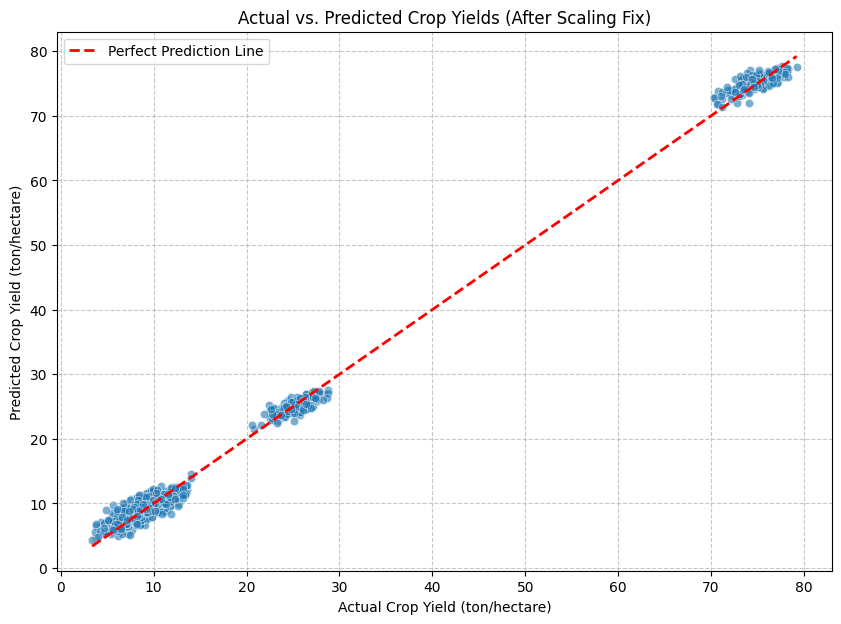

In [12]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual Crop Yield', y='Predicted Crop Yield', data=results_df_1, alpha=0.6)
plt.plot([results_df_1['Actual Crop Yield'].min(), results_df_1['Actual Crop Yield'].max()],
         [results_df_1['Actual Crop Yield'].min(), results_df_1['Actual Crop Yield'].max()],
         color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Crop Yields (After Scaling Fix)')
plt.xlabel('Actual Crop Yield (ton/hectare)')
plt.ylabel('Predicted Crop Yield (ton/hectare)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

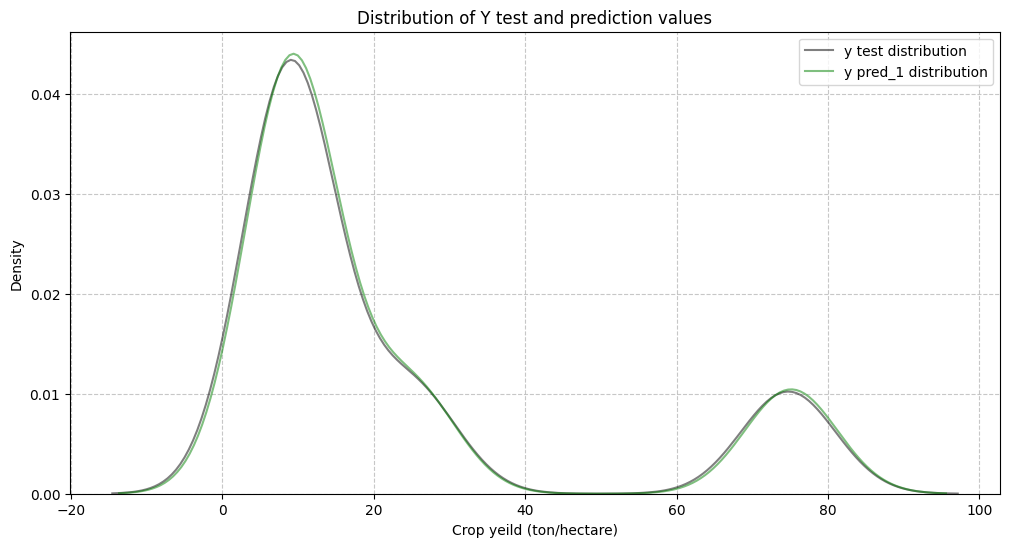

In [28]:
plt.figure(figsize=(12, 6))
sns.kdeplot(y_test_original, color='black', label='y test distribution', alpha=0.5)
sns.kdeplot(y_pred_original_1, color='green', label='y pred_1 distribution', alpha=0.5)
plt.title('Distribution of Y test and prediction values')
plt.xlabel('Crop yeild (ton/hectare)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

MODEL 2 TRAINING

In [75]:
import tensorflow as tf
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(25),
  tf.keras.layers.Dense(36,activation= 'relu'),
  tf.keras.layers.Dense(48,activation= 'elu'),
  # tf.keras.layers.Dropout(0.1),
  tf.keras.layers.Dense(64,activation = 'gelu'),
  tf.keras.layers.Dense(81),
  tf.keras.layers.Dense(1),
])

model_2.compile(loss='mae',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

print("Retraining model_2 with newly selected features...")
model_2.fit(X_train_selected, y_train, epochs=30, validation_data=(X_val_selected, y_val))

Retraining model_2 with newly selected features...
Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1830 - mae: 0.1830 - val_loss: 0.1889 - val_mae: 0.1889
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1691 - mae: 0.1691 - val_loss: 0.1851 - val_mae: 0.1851
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1659 - mae: 0.1659 - val_loss: 0.1876 - val_mae: 0.1876
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1634 - mae: 0.1634 - val_loss: 0.1727 - val_mae: 0.1727
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1571 - mae: 0.1571 - val_loss: 0.1672 - val_mae: 0.1672
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1507 - mae: 0.1507 - val_loss: 0.1636 - val_mae: 0.1636
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1493 - mae: 0.1493 - val_loss: 0.1632 - val_mae: 0.1632
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1475 - mae: 0.1475 - val_loss: 0.1559 - val_mae: 0.1559
Epoch

In [76]:
y_pred_scaled_2 = model_2.predict(X_test_selected)
model_2_results = model_2.evaluate(X_test_selected, y_test)
print(f"Test Loss: {model_2_results[0]:.4f}")
print(f"Test MAE: {model_2_results[1]:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0121 - mae: 0.0121 
Test Loss: 0.0122
Test MAE: 0.0122


In [82]:
from sklearn.metrics import mean_absolute_error

with open('scalers.pkl', 'rb') as f:
    scaling_pipeline_X, y_scaler = pickle.load(f)

y_test_original = y_scaler.inverse_transform(y_test.values.reshape(-1, 1)).flatten()
y_pred_original_2 = y_scaler.inverse_transform(y_pred_scaled_2).flatten()

true_mae_2 = mean_absolute_error(y_test_original, y_pred_original_2)
print(f"Model 2 True MAE on original scale: {true_mae_2:.4f}")

results_df_2 = pd.DataFrame({
    'Actual Crop Yield': y_test_original,
    'Predicted Crop Yield': y_pred_original_2
})

display(results_df_2)

Model 2 True MAE on original scale: 0.9677


,Actual Crop Yield,Predicted Crop Yield
0,74.60,74.759644
1,24.70,24.188951
2,7.89,8.916524
3,77.25,74.809364
4,7.54,10.069005
...,...,...
995,10.84,9.911292
996,22.61,22.767982
997,10.13,10.513961
998,23.69,23.326864


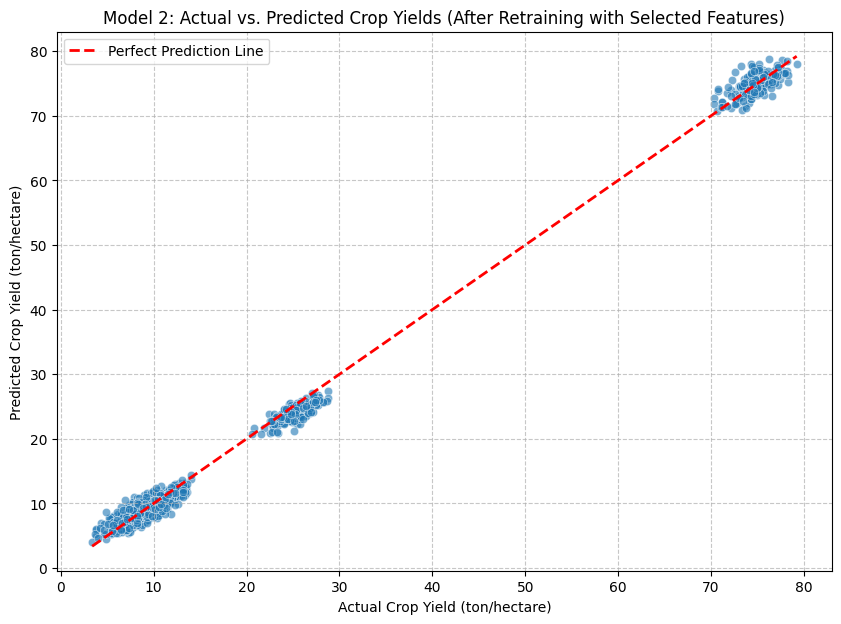

In [83]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual Crop Yield', y='Predicted Crop Yield', data=results_df_2, alpha=0.6)
plt.plot([results_df_2['Actual Crop Yield'].min(), results_df_2['Actual Crop Yield'].max()],
         [results_df_2['Actual Crop Yield'].min(), results_df_2['Actual Crop Yield'].max()],
         color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.title('Model 2: Actual vs. Predicted Crop Yields (After Retraining with Selected Features)')
plt.xlabel('Actual Crop Yield (ton/hectare)')
plt.ylabel('Predicted Crop Yield (ton/hectare)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

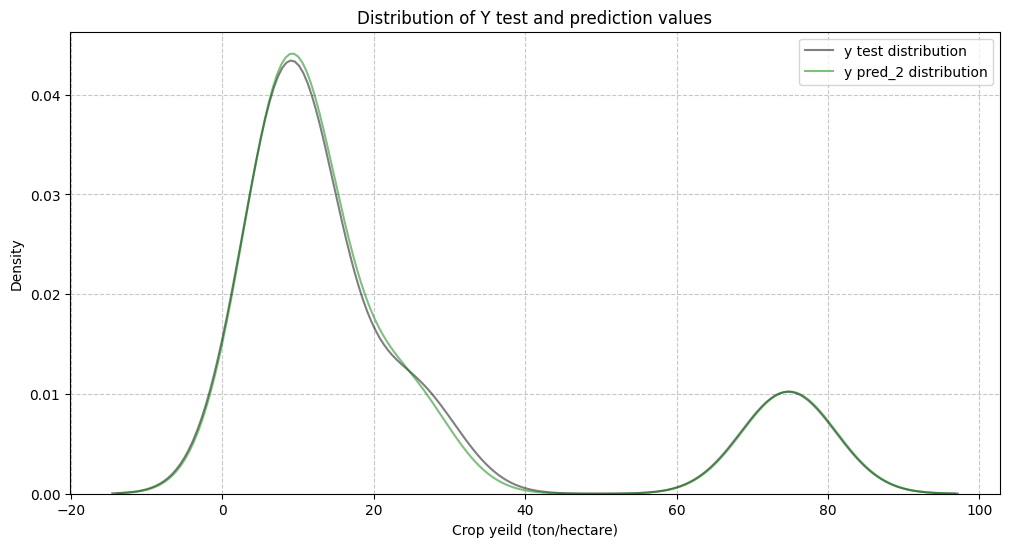

In [84]:
plt.figure(figsize=(12, 6))
sns.kdeplot(y_test_original, color='black', label='y test distribution', alpha=0.5)
sns.kdeplot(y_pred_original_2, color='green', label='y pred_2 distribution', alpha=0.5)
plt.title('Distribution of Y test and prediction values')
plt.xlabel('Crop yeild (ton/hectare)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

COMPARING THE PREDICTIONS

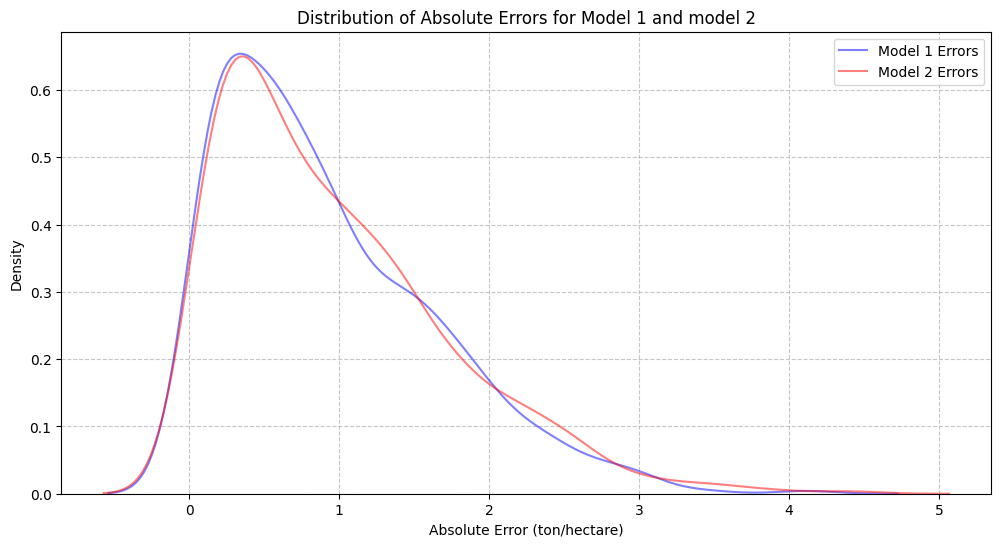

In [86]:
absolute_errors_1 = np.abs(y_test_original - y_pred_original_1)
absolute_errors_2 = np.abs(y_test_original - y_pred_original_2)

plt.figure(figsize=(12, 6))
sns.kdeplot(absolute_errors_1, color='blue', label='Model 1 Errors', alpha=0.5)
sns.kdeplot(absolute_errors_2, color='red', label='Model 2 Errors', alpha=0.5)
plt.title('Distribution of Absolute Errors for Model 1 and model 2')
plt.xlabel('Absolute Error (ton/hectare)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [87]:
with open('Model_1.pkl', 'wb') as f:
    pickle.dump((model_1), f)

In [88]:
with open('Model_2.pkl', 'wb') as f:
    pickle.dump((model_2), f)